# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [1]:
import cv2
import numpy as np
from PIL import Image
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [2]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2]   #shape have [:3] h,w,c (color) but here we don't need it so it's [:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

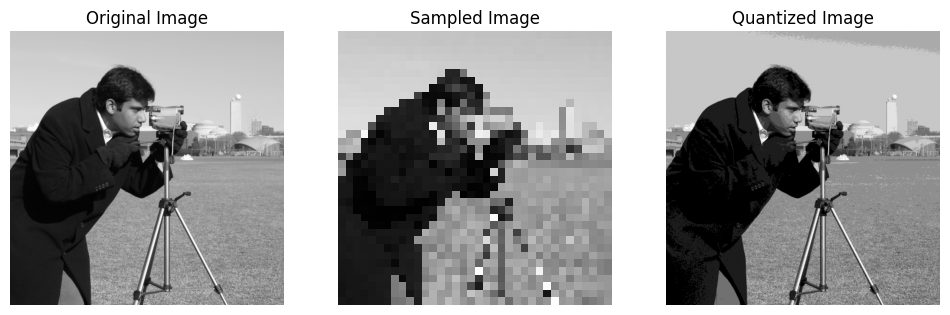

In [3]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

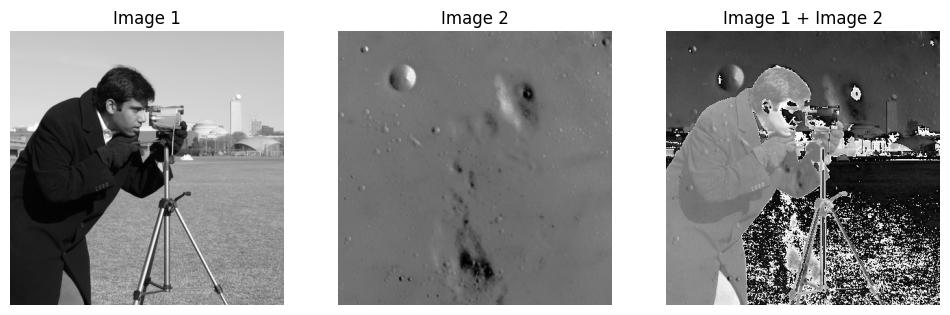

In [4]:
#we have 4 steps

#1             PIL         arrays    (change arrary to images to use 'resize' )
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

#2 to be the same size
new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS) #Lanczos is better than inter_nearest >> choose the nearest but first calculate then choose
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

#3   convert then to arrays again so we can calculate
im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

#4 convert to image again after added them
addition = im1arr + im2arr
result_image = Image.fromarray(addition)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

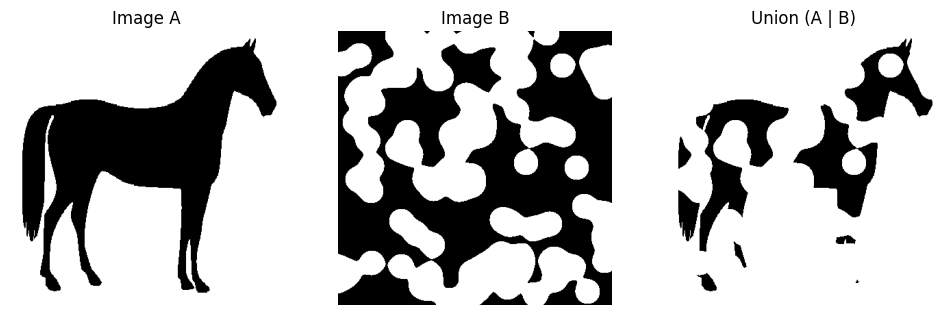

In [ ]:
#the same steps as before

#downlaod
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

It dictates how many pixels are kept to represent the image dimensions.
So decreasing the sampling rate reduces the total number of pixels. This causes a loss of fine spatial details 
resulting in a pixelated or blocky appearance, as fewer pixels are used to represent the original scene.

here trying multiple valuse of the sampling factor 



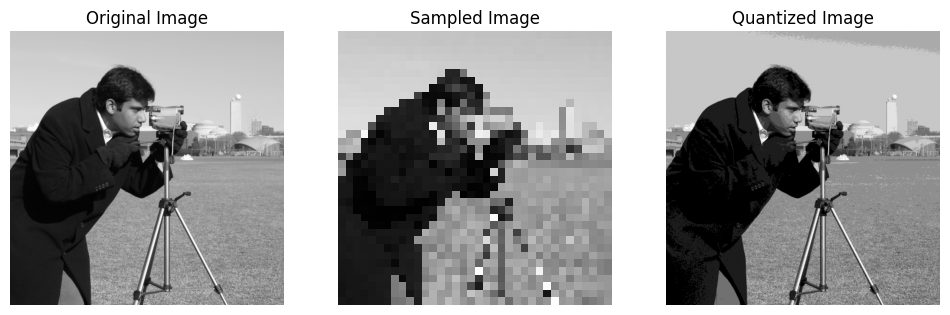

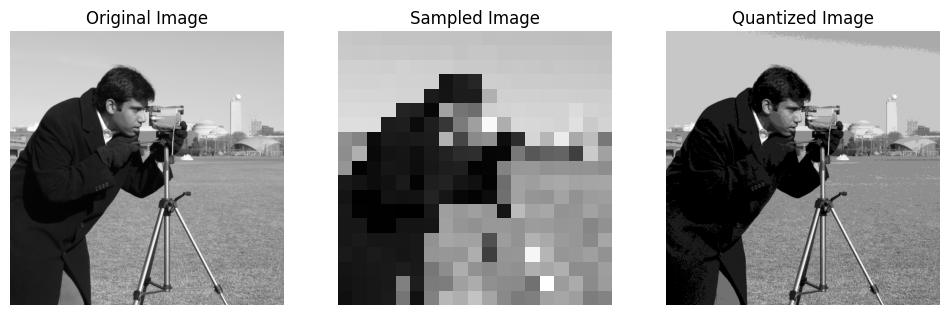

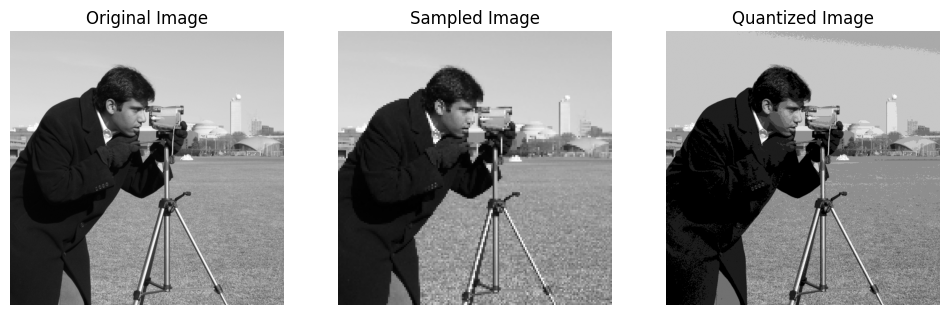

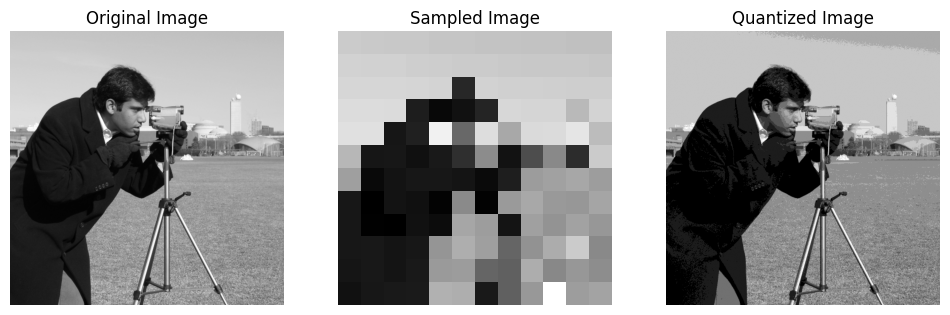

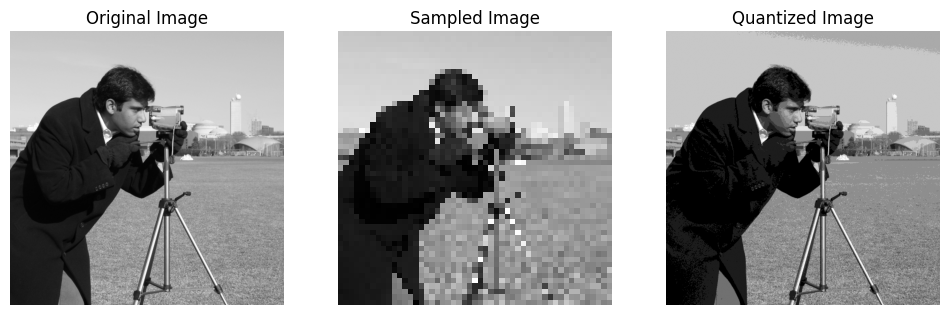

In [20]:
print("It dictates how many pixels are kept to represent the image dimensions.")
print("So decreasing the sampling rate reduces the total number of pixels. This causes a loss of fine spatial details ")
print("resulting in a pixelated or blocky appearance, as fewer pixels are used to represent the original scene.")

print("\nhere trying multiple valuse of the sampling factor \n")

original_image = data.camera()

s_factor = 14
s_factor1 = 26
s_factor2 = 3
s_factor3 = 40
s_factor4 = 10
q_levels = 9

samp_image = sample_image(original_image, s_factor)
samp_image1 = sample_image(original_image, s_factor1)
samp_image2 = sample_image(original_image, s_factor2)
samp_image3 = sample_image(original_image, s_factor3)
samp_image4 = sample_image(original_image, s_factor4)
q_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, samp_image, q_image)
plot_images(original_image, samp_image1, q_image)
plot_images(original_image, samp_image2, q_image)
plot_images(original_image, samp_image3, q_image)
plot_images(original_image, samp_image4, q_image)

### 1b) Effect of quantization levels (intensity resolution)

It dictates how many distinct gray levels are kept to represent the brightness of each pixel.
So decreasing the number of quantization levels limits the available shades of gray.
This destroys smooth color transitions and gradients

here trying multiple valuse of the quantization levels 



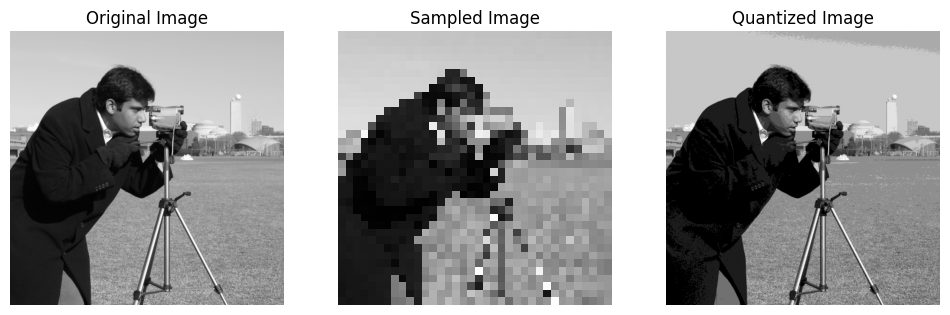

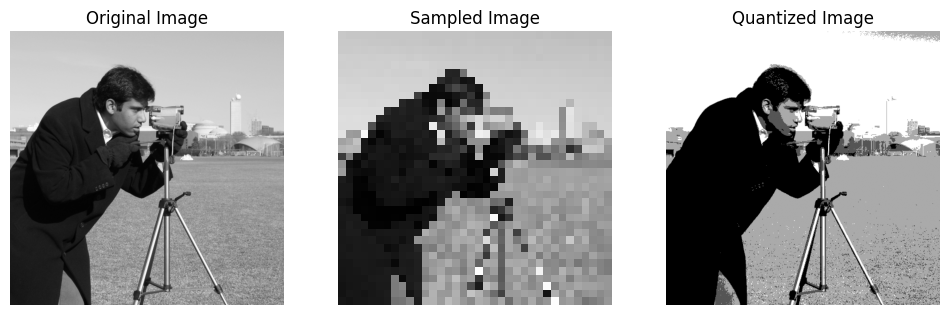

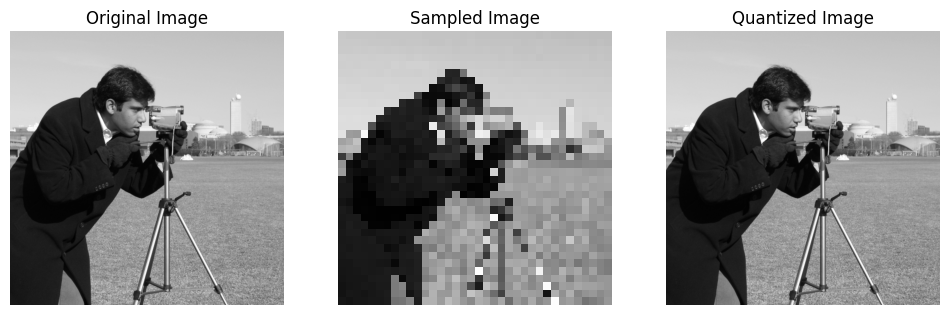

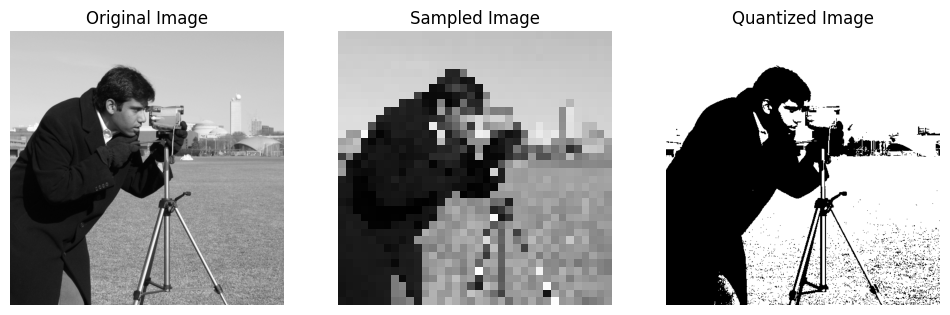

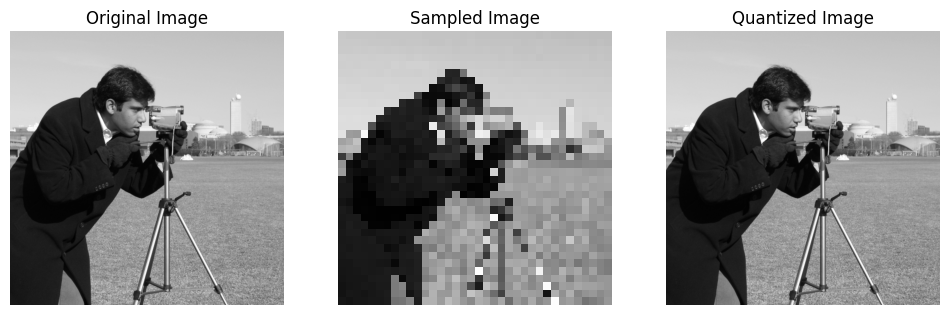

In [21]:
print("It dictates how many distinct gray levels are kept to represent the brightness of each pixel.")
print("So decreasing the number of quantization levels limits the available shades of gray.")
print("This destroys smooth color transitions and gradients")

print("\nhere trying multiple valuse of the quantization levels \n")

original_image = data.camera()

s_factor = 14
q_levels = 9
q_levels1 = 4
q_levels2 = 189
q_levels3 = 2
q_levels4 = 255

samp_image = sample_image(original_image, s_factor)
q_image = quantize_image(original_image, q_levels)
q_image1 = quantize_image(original_image, q_levels1)
q_image2 = quantize_image(original_image, q_levels2)
q_image3 = quantize_image(original_image, q_levels3)
q_image4 = quantize_image(original_image, q_levels4)

plot_images(original_image, samp_image, q_image)
plot_images(original_image, samp_image, q_image1)
plot_images(original_image, samp_image, q_image2)
plot_images(original_image, samp_image, q_image3)
plot_images(original_image, samp_image, q_image4)

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

### 2a) Subtract two images

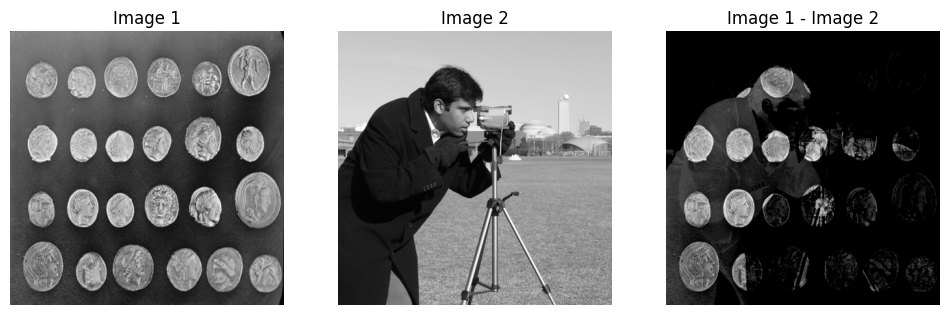

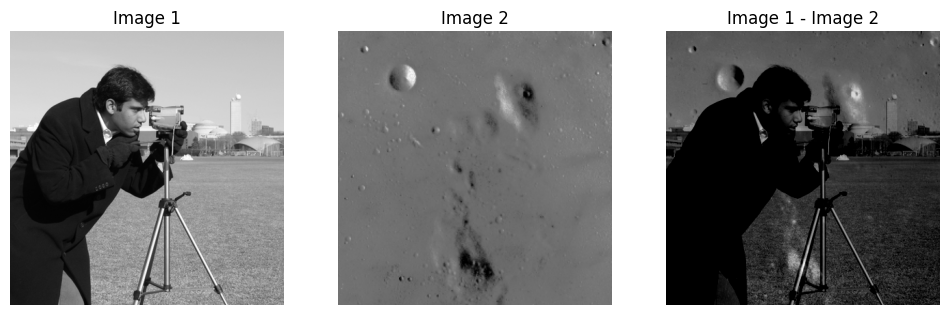

In [23]:
img1 = Image.fromarray(data.coins())
img2 = Image.fromarray(data.camera())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS) #Lanczos is better than inter_nearest >> choose the nearest but first calculate then choose
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

sub = cv2.subtract(im1arr, im2arr)
result_image = Image.fromarray(sub)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 - Image 2'), plt.axis('off')
plt.show()


img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS) #Lanczos is better than inter_nearest >> choose the nearest but first calculate then choose
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

sub = cv2.subtract(im1arr, im2arr)
result_image = Image.fromarray(sub)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 - Image 2'), plt.axis('off')
plt.show()

### 2b) Add image with constant value 175

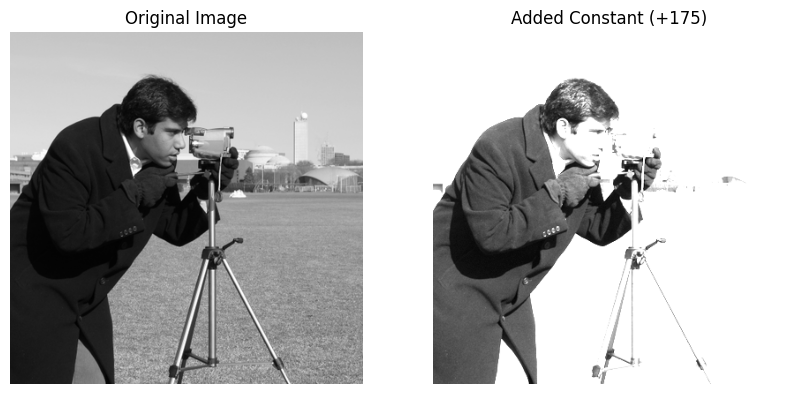

In [25]:
img1 = Image.fromarray(data.camera())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)

constant_matrix = np.full(im1arr.shape, 175, dtype=np.uint8)

added_arr = cv2.add(im1arr, constant_matrix)

result_image = Image.fromarray(added_arr)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(img1, cmap='gray'), plt.title('Original Image'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(result_image, cmap='gray'), plt.title('Added Constant (+175)'), plt.axis('off')
plt.show()

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

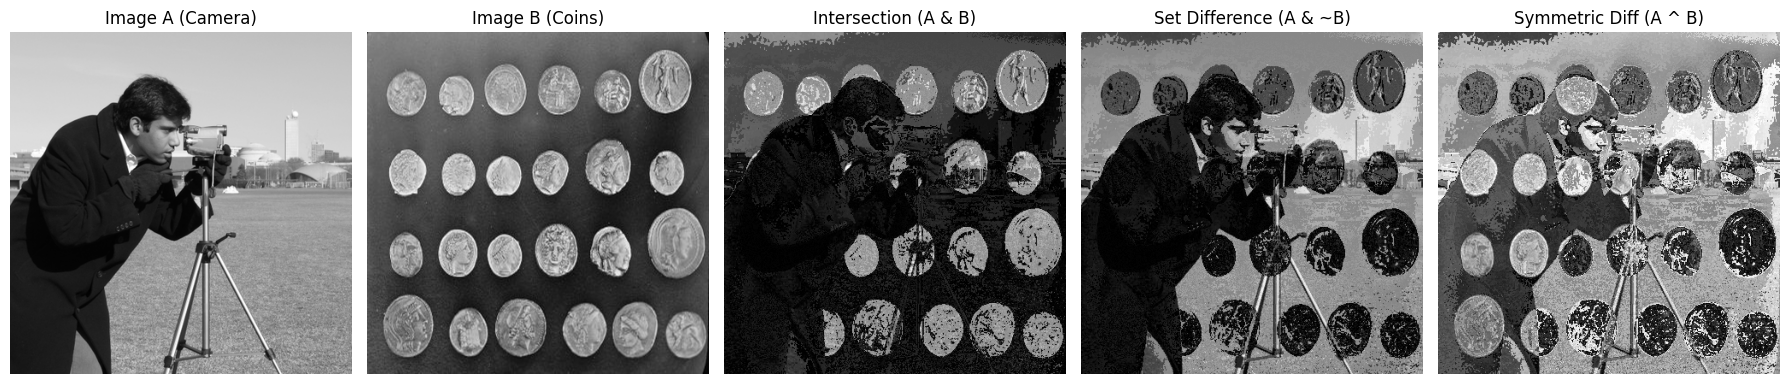

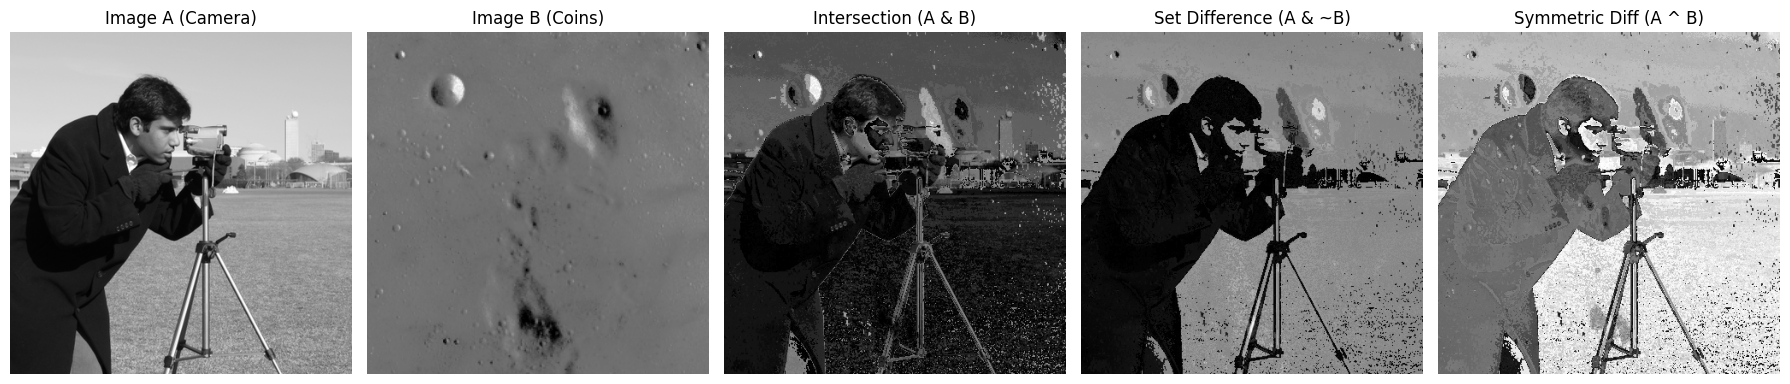

In [27]:
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.coins())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

A = np.asarray(img1)
B = np.asarray(img2)

# 2c) Intersection (A & B)   Keeps bits set in both
intersection_arr = cv2.bitwise_and(A, B)

# 2d) Set Difference (A & ~B) -> (A - B)  Keeps bits in A but not in B
B_inverted = cv2.bitwise_not(B)
set_diff_arr = cv2.bitwise_and(A, B_inverted)

# 2e) Symmetric Difference (A ^ B)  Keeps bits in A or B but not both
sym_diff_arr = cv2.bitwise_xor(A, B)

img_intersection = Image.fromarray(intersection_arr)
img_set_diff = Image.fromarray(set_diff_arr)
img_sym_diff = Image.fromarray(sym_diff_arr)


plt.figure(figsize=(18, 6))

plt.subplot(1, 5, 1)
plt.imshow(img1, cmap='gray')
plt.title('Image A (Camera)')
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(img2, cmap='gray')
plt.title('Image B (Coins)')
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(img_intersection, cmap='gray')
plt.title('Intersection (A & B)')
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(img_set_diff, cmap='gray')
plt.title('Set Difference (A & ~B)')
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(img_sym_diff, cmap='gray')
plt.title('Symmetric Diff (A ^ B)')
plt.axis('off')

plt.tight_layout()
plt.show()


img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

A = np.asarray(img1)
B = np.asarray(img2)

# 2c) Intersection (A & B)   Keeps bits set in both
intersection_arr = cv2.bitwise_and(A, B)

# 2d) Set Difference (A & ~B) -> (A - B)  Keeps bits in A but not in B
B_inverted = cv2.bitwise_not(B)
set_diff_arr = cv2.bitwise_and(A, B_inverted)

# 2e) Symmetric Difference (A ^ B)  Keeps bits in A or B but not both
sym_diff_arr = cv2.bitwise_xor(A, B)

img_intersection = Image.fromarray(intersection_arr)
img_set_diff = Image.fromarray(set_diff_arr)
img_sym_diff = Image.fromarray(sym_diff_arr)


plt.figure(figsize=(18, 6))

plt.subplot(1, 5, 1)
plt.imshow(img1, cmap='gray')
plt.title('Image A (Camera)')
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(img2, cmap='gray')
plt.title('Image B (Coins)')
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(img_intersection, cmap='gray')
plt.title('Intersection (A & B)')
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(img_set_diff, cmap='gray')
plt.title('Set Difference (A & ~B)')
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(img_sym_diff, cmap='gray')
plt.title('Symmetric Diff (A ^ B)')
plt.axis('off')

plt.tight_layout()
plt.show()